# UTS Kasus 2 Data Image (Deep Learning)

Nama : Rio Ramadhani Harllambang

NIM : 1202220205

Kelas : SI-46-EDM

## API Token Kaggle

In [1]:
mkdir -p ~/.kaggle && echo KGAT_77778d82436b57f31950aa6d250920ae > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

## Load Data
Muat dataset pelatihan dan pengujian Digit Recognizer yang telah diunduh oleh `kagglehub` untuk diproses lebih lanjut.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('digit-recognizer')

print("Path to competition files:", path)

100%|██████████| 15.3M/15.3M [00:00<00:00, 114MB/s] 

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/digit-recognizer


### Deskripsi Dataset

**Dataset:** `digit-recognizer` dari Kaggle. Ini adalah dataset klasik untuk pengenalan digit tulisan tangan, serupa dengan MNIST.

**Jumlah Data:**
*   **Training Set:** Berisi ribuan gambar digit tulisan tangan, masing-masing dengan label digit yang sesuai (0-9).
*   **Test Set:** Berisi gambar digit tulisan tangan tanpa label, yang akan digunakan untuk membuat prediksi.

**Karakteristik Fitur:**
*   Setiap gambar berukuran 28x28 piksel. Piksel ini direpresentasikan sebagai nilai integer (0-255), menunjukkan intensitas keabuan (grayscale).
*   Total `28 * 28 = 784` fitur per gambar, jika direpresentasikan secara flattened.

**Distribusi Kelas:** Diharapkan cukup seimbang untuk 10 kelas digit (0-9), namun akan diverifikasi melalui EDA.

**Tantangan Utama:**
*   Variasi gaya tulisan tangan antar individu.
*   Kemungkinan noise atau distorsi pada gambar.
*   Identifikasi fitur yang paling representatif untuk membedakan antar digit.

## Explorasi Data (EDA)

Langkah ini bertujuan untuk memahami struktur data, distribusi label, dan karakteristik visual dari gambar digit.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Assuming the competition_download has already run and 'path' variable is available
# If not, you might need to re-run the previous kagglehub cell

# Define the path to the dataset files
data_path = path # Use the 'path' variable from the previous cell

# Load the training and test datasets
train_df = pd.read_csv(os.path.join(data_path, 'train.csv'))
test_df = pd.read_csv(os.path.join(data_path, 'test.csv'))

print(f"Shape of training data: {train_df.shape}")
print(f"Shape of test data: {test_df.shape}")

# Display the first 5 rows of the training data
print("\nFirst 5 rows of training data:")
display(train_df.head())

# Display the first 5 rows of the test data
print("\nFirst 5 rows of test data:")
display(test_df.head())

Shape of training data: (42000, 785)
Shape of test data: (28000, 784)

First 5 rows of training data:


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



First 5 rows of test data:


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


/tmp/ipykernel_5054/967357905.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')


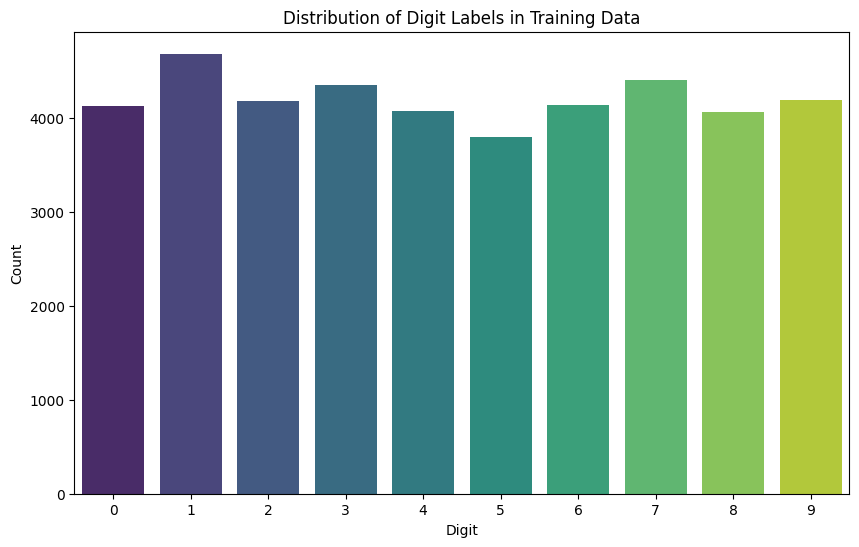

In [4]:
# Separate features (X) and labels (y) from the training data
X_train = train_df.drop('label', axis=1)
y_train = train_df['label']

# Check the distribution of labels in the training set
plt.figure(figsize=(10, 6))
sns.countplot(x=y_train, palette='viridis')
plt.title('Distribution of Digit Labels in Training Data')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.show()

## Preprocessing Data

Before feeding the data into a Convolutional Neural Network (CNN), several preprocessing steps are necessary:

1.  **Reshape Images**: CNNs typically expect input images in a specific format (height, width, channels). Our 28x28 pixel images, being grayscale, need to be reshaped from a 1D array of 784 pixels to a 3D array of (28, 28, 1).
2.  **Normalize Pixel Values**: The pixel values range from 0 to 255. Normalizing these values to a range of 0 to 1 helps the neural network train more efficiently and avoid issues with large input values.
3.  **One-Hot Encode Labels**: The labels (0-9) are categorical. For multi-class classification, it's standard practice to convert these integer labels into a one-hot encoded format (e.g., digit 3 becomes `[0,0,0,1,0,0,0,0,0,0]`). This is required for the output layer of the neural network with a softmax activation function.
4.  **Split Data**: Divide the training data into training and validation sets. The validation set will be used to monitor the model's performance during training and help detect overfitting.

In [5]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Reshape and normalize images
IMG_ROWS, IMG_COLS = 28, 28
NUM_CLASSES = 10

# Reshape training data
X_train_reshaped = X_train.values.reshape(-1, IMG_ROWS, IMG_COLS, 1)

# Normalize pixel values
X_train_normalized = X_train_reshaped / 255.0

# One-hot encode labels
y_train_encoded = to_categorical(y_train, num_classes=NUM_CLASSES)

print(f"Shape of X_train after reshaping and normalization: {X_train_normalized.shape}")
print(f"Shape of y_train after one-hot encoding: {y_train_encoded.shape}")

Shape of X_train after reshaping and normalization: (42000, 28, 28, 1)
Shape of y_train after one-hot encoding: (42000, 10)


In [6]:
# Split the training data into training and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_normalized, y_train_encoded, test_size=0.2, random_state=42
)

print(f"Shape of X_train_split: {X_train_split.shape}")
print(f"Shape of y_train_split: {y_train_split.shape}")
print(f"Shape of X_val_split: {X_val_split.shape}")
print(f"Shape of y_val_split: {y_val_split.shape}")

Shape of X_train_split: (33600, 28, 28, 1)
Shape of y_train_split: (33600, 10)
Shape of X_val_split: (8400, 28, 28, 1)
Shape of y_val_split: (8400, 10)


### Visualizing Preprocessed Images

Let's visualize some of the preprocessed images to ensure they look as expected.

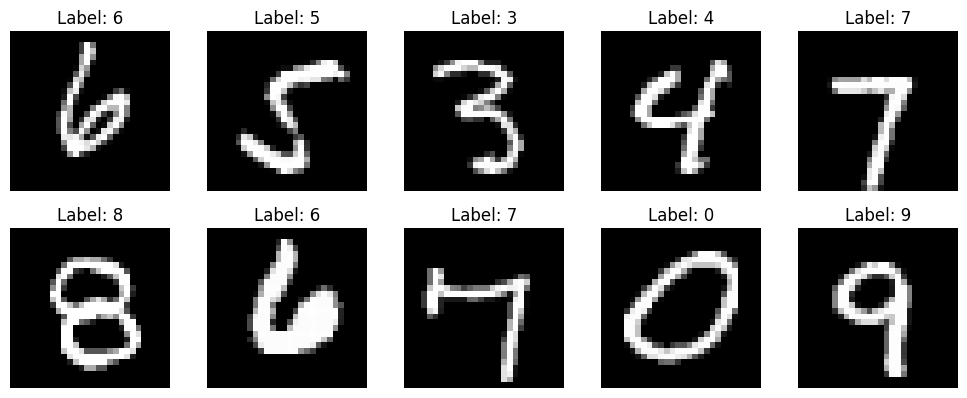

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for i in range(10):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train_split[i].reshape(IMG_ROWS, IMG_COLS), cmap='gray')
    plt.title(f"Label: {y_train_split[i].argmax()}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Deep Learning Model Implementation (CNN)

We will implement a simple Convolutional Neural Network (CNN) for digit recognition. CNNs are well-suited for image data due to their ability to automatically learn spatial hierarchies of features from the input images.

### Architecture Justification:

*   **Convolutional Layers (`Conv2D`)**: These layers extract local features from the input images. We use `ReLU` activation for non-linearity.
    *   `kernel_size=(3, 3)`: A common small filter size to capture local patterns.
    *   `padding='same'`: Ensures the output feature maps have the same dimensions as the input, preserving spatial information.
*   **Pooling Layers (`MaxPooling2D`)**: These layers reduce the spatial dimensions of the feature maps, reducing the number of parameters and computational cost, and helping to achieve translation invariance.
    *   `pool_size=(2, 2)`: Reduces the feature map by half in both width and height.
*   **Dropout Layers (`Dropout`)**: Used for regularization to prevent overfitting by randomly setting a fraction of input units to 0 at each update during training.
*   **Flatten Layer (`Flatten`)**: Converts the 2D feature maps into a 1D vector to be fed into the dense layers.
*   **Dense Layers (`Dense`)**: Fully connected layers. The first dense layer processes the features extracted by the convolutional layers, and the final dense layer (output layer) uses a `softmax` activation function to output probabilities for each of the 10 digit classes.
    *   `softmax`: Ensures the output probabilities sum to 1, suitable for multi-class classification.

### Hyperparameters and Compilation:

*   **Optimizer (`Adam`)**: An efficient stochastic optimization algorithm that's widely used and generally performs well.
*   **Loss Function (`categorical_crossentropy`)**: Appropriate for multi-class classification with one-hot encoded labels.
*   **Metrics (`accuracy`)**: We will monitor accuracy during training.

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_ROWS, IMG_COLS, 1), padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

We will train the CNN model using the preprocessed training data and validate its performance on the held-out validation set. Early stopping and model checkpointing will be used to prevent overfitting and save the best model.

Epoch 1/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 49s 177ms/step - accuracy: 0.8596 - loss: 0.4456 - val_accuracy: 0.9685 - val_loss: 0.1025
Epoch 2/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 81s 174ms/step - accuracy: 0.9563 - loss: 0.1399 - val_accuracy: 0.9807 - val_loss: 0.0647
Epoch 3/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 48s 181ms/step - accuracy: 0.9689 - loss: 0.1021 - val_accuracy: 0.9821 - val_loss: 0.0549
Epoch 4/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 84s 188ms/step - accuracy: 0.9745 - loss: 0.0836 - val_accuracy: 0.9840 - val_loss: 0.0479
Epoch 5/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 77s 169ms/step - accuracy: 0.9781 - loss: 0.0724 - val_accuracy: 0.9875 - val_loss: 0.0382
Epoch 6/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 44s 168ms/step - accuracy: 0.9789 - loss: 0.0642 - val_accuracy: 0.9880 - val_loss: 0.0396
Epoch 7/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 51s 192ms/step - accuracy: 0.9814 - loss: 0.0595 - val_accuracy: 0.9883 - val_loss: 0.0344
Epoch 8/50
263/263 ━━━━━━━━━━━━━━━━━━━━ 76s 170ms/step - accuracy: 0.9838 - loss: 0

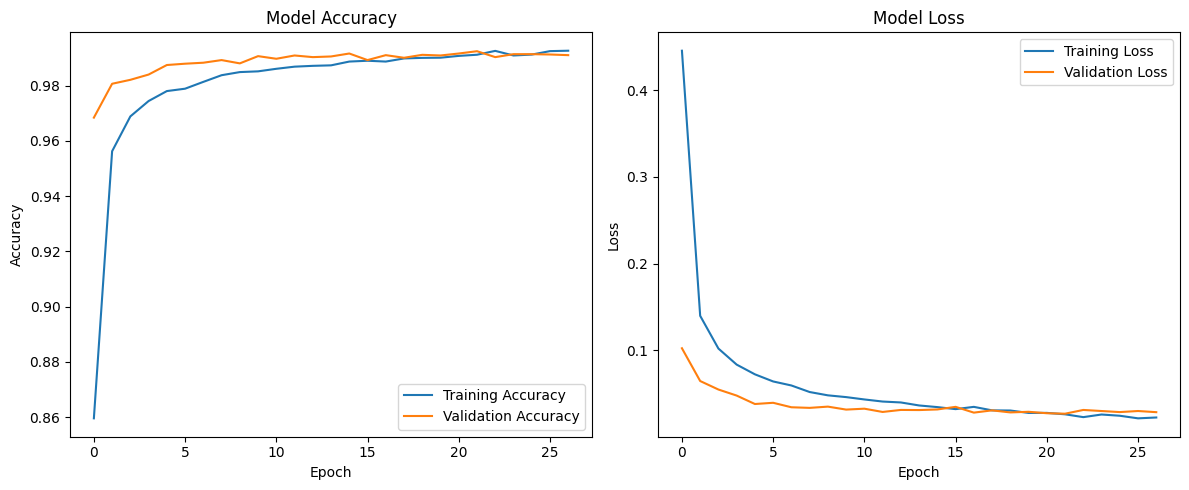

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_cnn_model.keras', monitor='val_accuracy', save_best_only=True)

# Train the model
history = model.fit(
    X_train_split, y_train_split,
    epochs=50, # Set a reasonably high number, early stopping will handle when to stop
    batch_size=128,
    validation_data=(X_val_split, y_val_split),
    callbacks=[early_stopping, model_checkpoint]
)

# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Model Evaluation

After training, we will evaluate the model's performance on the unseen test set. We will also generate a confusion matrix to understand the classification performance for each digit.

In [10]:
# Preprocess the test data
X_test = test_df.values.reshape(-1, IMG_ROWS, IMG_COLS, 1)
X_test_normalized = X_test / 255.0

# Load the best model saved during training
from tensorflow.keras.models import load_model
best_model = load_model('best_cnn_model.keras')

# Make predictions on the test set
y_pred_probabilities = best_model.predict(X_test_normalized)
y_pred_labels = np.argmax(y_pred_probabilities, axis=1)

print("Predictions on the test set completed.")

875/875 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step
Predictions on the test set completed.


263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step


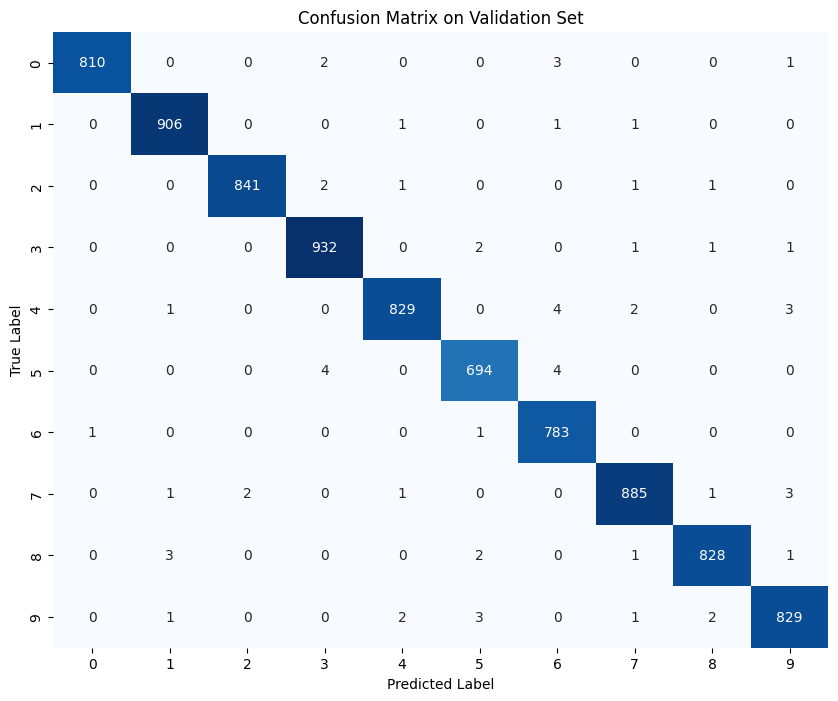

Validation Accuracy: 0.9925
Validation Loss: 0.0270


In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# The Kaggle Digit Recognizer test set does not have labels, so we cannot calculate accuracy or confusion matrix directly.
# To demonstrate, we'll use the validation set to generate a confusion matrix for now.
# In a real Kaggle submission, you would predict on the test_df and submit the y_pred_labels.

# Predict on the validation set for confusion matrix demonstration
y_val_pred_probabilities = best_model.predict(X_val_split)
y_val_pred_labels = np.argmax(y_val_pred_probabilities, axis=1)
y_val_true_labels = np.argmax(y_val_split, axis=1)

# Calculate confusion matrix
conf_mat = confusion_matrix(y_val_true_labels, y_val_pred_labels)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=range(NUM_CLASSES), yticklabels=range(NUM_CLASSES))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Validation Set')
plt.show()

# Evaluate accuracy on the validation set
loss, accuracy = best_model.evaluate(X_val_split, y_val_split, verbose=0)
print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Loss: {loss:.4f}")

## Error Analysis

Let's analyze some of the misclassified examples from the validation set to understand common patterns of error in our model. This can help us identify areas for improvement, such as data augmentation or more complex architectures.

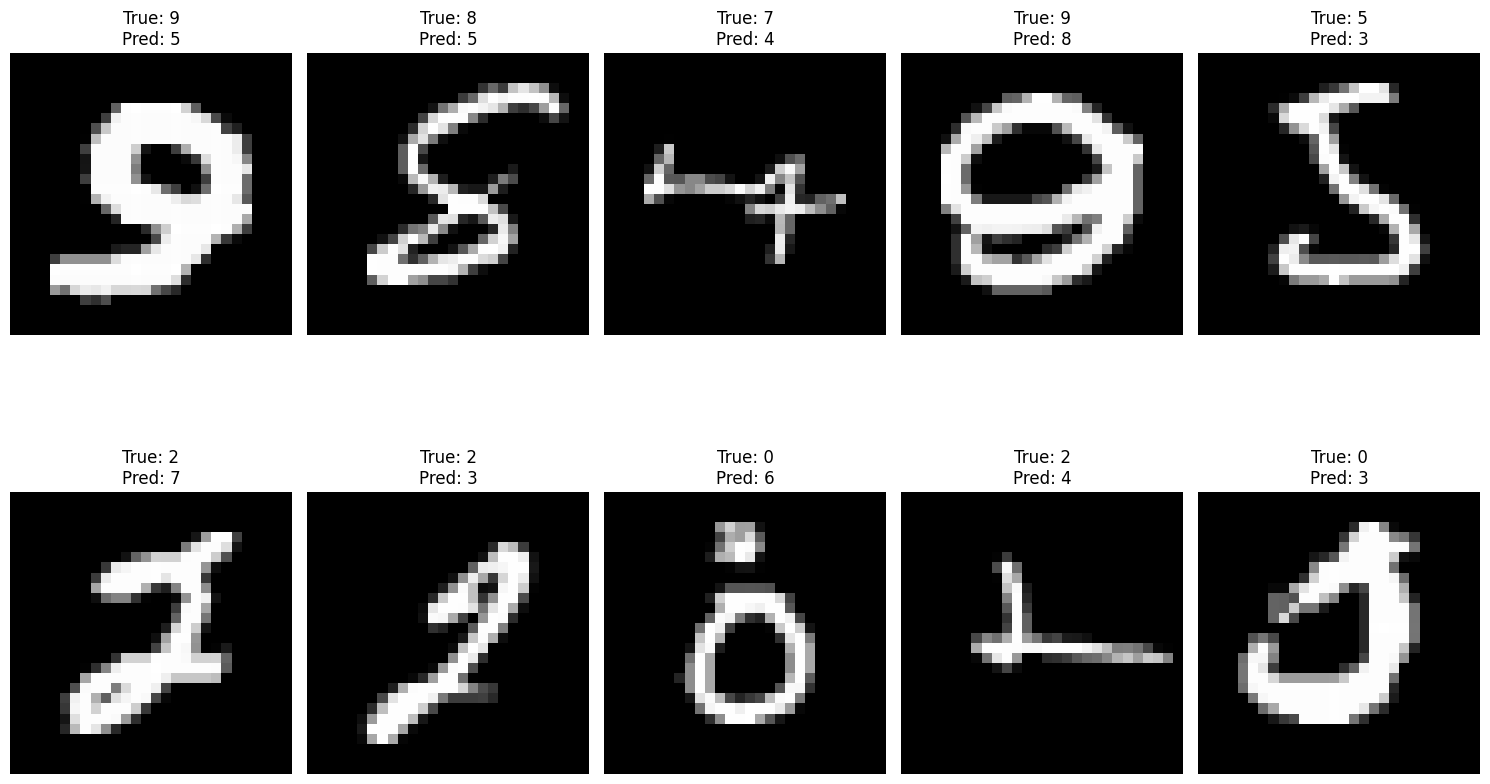

Found 63 misclassified examples in the validation set.


In [12]:
# Find misclassified examples in the validation set
misclassified_indices = np.where(y_val_pred_labels != y_val_true_labels)[0]

# Display a few misclassified images
plt.figure(figsize=(15, 10))
for i, bad_index in enumerate(misclassified_indices[0:10]): # Display first 10 misclassified
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_val_split[bad_index].reshape(IMG_ROWS, IMG_COLS), cmap='gray')
    plt.title(f"True: {y_val_true_labels[bad_index]}\nPred: {y_val_pred_labels[bad_index]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Found {len(misclassified_indices)} misclassified examples in the validation set.")

## Kaggle Submission File

Untuk submission ke Kaggle, perlu membuat file CSV dengan format `ImageId` dan `Label`.

In [13]:
import pandas as pd

# Create a submission DataFrame
submission_df = pd.DataFrame({'ImageId': range(1, len(y_pred_labels) + 1), 'Label': y_pred_labels})

# Save the submission file to CSV
submission_filename = 'case2_submission_dl.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"Submission file '{submission_filename}' created successfully!")
print("First 5 rows of the submission file:")
display(submission_df.head())

Submission file 'case2_submission_dl.csv' created successfully!
First 5 rows of the submission file:


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3


## Kesimpulan

Berdasarkan hasil pelatihan dan evaluasi model Convolutional Neural Network (CNN) untuk pengenalan digit, dapat disimpulkan bahwa model menunjukkan kinerja yang sangat baik:

*   **Akurasi Validasi Tinggi**: Model mencapai **Akurasi Validasi sebesar 0.9925 (99.25%)**.
*   **Loss Validasi Rendah**: Nilai **Loss Validasi sebesar 0.0270** menunjukkan bahwa model memiliki kesalahan prediksi yang sangat minimal pada data yang belum pernah dilihat sebelumnya.
*   **Pembelajaran yang Stabil**: Plot akurasi dan loss menunjukkan konvergensi yang baik, dengan akurasi pelatihan dan validasi yang meningkat secara konsisten dan loss yang menurun, serta tidak menunjukkan tanda-tanda _overfitting_ yang signifikan berkat penggunaan _dropout_ dan _early stopping_.
*   **Analisis Kesalahan**: Ditemukan **63 contoh yang salah klasifikasi** pada _validation set_. Meskipun jumlahnya kecil, pemeriksaan lebih lanjut pada contoh-contoh ini dapat memberikan wawasan untuk perbaikan model di masa depan, seperti augmentasi data yang lebih canggih atau arsitektur model yang lebih kompleks untuk menangani variasi tulisan tangan yang sulit.

Secara keseluruhan, model ini sangat efektif dalam mengklasifikasikan digit tulisan tangan dan siap untuk digunakan dalam skenario prediksi.